# 1. Input validation and cropland sampling

In [1]:
from pathlib import Path
from contextlib import ExitStack
import os, json

os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(max(1, (os.cpu_count() or 2) - 1)))
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import rasterio
from matplotlib.colors import ListedColormap
from rasterio.crs import CRS
from rasterio.transform import array_bounds, xy
from rasterio.windows import Window
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform as transform_coords
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display
from importlib.metadata import version
from datetime import datetime, timezone
import hashlib
import platform

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'climate_soil_classification.ipynb').exists():
    candidates = list(NOTEBOOK_DIR.glob('*/climate_soil_classification.ipynb'))
    if len(candidates) != 1:
        raise FileNotFoundError('Open Jupyter in the folder containing the notebooks.')
    NOTEBOOK_DIR = candidates[0].parent
OUTPUT_DIR = NOTEBOOK_DIR / 'cropland_raster_strata'
RASTER_OUTPUT_DIR = NOTEBOOK_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Edit input paths and analysis settings here.
RASTER_DIR = NOTEBOOK_DIR / 'rasters'
SITE_EXCEL = NOTEBOOK_DIR / 'meta_data_raw.xlsx'
FEATURES = ['MAP', 'MAT', 'pH', 'SOC', 'srad', 'TN', 'vapr', 'CEC', 'Clay']
FEATURE_PATHS = [RASTER_DIR / f'{name}_cropped.tif' for name in FEATURES]
CROPLAND_PATH = RASTER_DIR / 'cropland_cropped.tif'
RANDOM_STATE = 42
SAMPLE_SIZE = 150_000
METRIC_SAMPLE_SIZE = 10_000
PCA_TARGET = 0.90
K_VALUES = range(3, 13)
SPATIAL_WEIGHTS = (0.0, 0.25, 0.5, 1.0)
SPATIAL_WEIGHT = 1.0
SITE_WEIGHT = 1.0
SPATIAL_SCALE_M = 500_000.0
MIN_CLASS_SHARE = 0.01
N_INIT = 20
ALBERS_RESOLUTION_M = 1000.0
ALBERS_NAME = 'Albers_Conic_Area'
ALBERS_CRS = CRS.from_proj4(
    '+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105 '
    '+datum=WGS84 +units=m +no_defs')

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def input_fingerprints(paths):
    return [{'name': p.name, 'bytes': p.stat().st_size, 'sha256': sha256_file(p)} for p in paths]

def raster_values_sha256(path):
    digest = hashlib.sha256()
    with rasterio.open(path) as src:
        for row in range(0, src.height, 128):
            window = Window(0, row, src.width, min(128, src.height - row))
            digest.update(src.read(1, window=window).astype('<i2').tobytes())
    return digest.hexdigest()

def read_features(sources, window):
    values = np.ma.column_stack([src.read(1, window=window, masked=True).ravel() for src in sources])
    return values.astype('float64').filled(np.nan)

def estimator_state(estimator):
    state = {}
    for name, value in vars(estimator).items():
        if name == 'labels_':
            continue
        if isinstance(value, np.ndarray):
            state[name] = {'array': value.tolist(), 'dtype': str(value.dtype)}
        else:
            state[name] = value.item() if isinstance(value, np.generic) else value
    return state

def add_lonlat_grid(ax, bounds, crs):
    for lon in range(70, 141, 10):
        xs, ys = transform_coords('EPSG:4326', crs, np.full(600, lon), np.linspace(0, 65, 600))
        ax.plot(xs, ys, color='gray', linewidth=.5, alpha=.45)
        for j in range(len(ys) - 1):
            if ys[j] <= bounds.bottom < ys[j + 1]:
                x = xs[j] + (xs[j + 1] - xs[j]) * (bounds.bottom - ys[j]) / (ys[j + 1] - ys[j])
                if bounds.left <= x <= bounds.right:
                    ax.annotate(f'{lon}°E', (x, bounds.bottom), xytext=(0, -5),
                                textcoords='offset points', ha='center', va='top', fontsize=8)
    for lat in range(10, 61, 10):
        xs, ys = transform_coords('EPSG:4326', crs, np.linspace(50, 160, 800), np.full(800, lat))
        ax.plot(xs, ys, color='gray', linewidth=.5, alpha=.45)
        for j in range(len(xs) - 1):
            if xs[j] <= bounds.left < xs[j + 1]:
                y = ys[j] + (ys[j + 1] - ys[j]) * (bounds.left - xs[j]) / (xs[j + 1] - xs[j])
                if bounds.bottom <= y <= bounds.top:
                    ax.annotate(f'{lat}°N', (bounds.left, y), xytext=(-5, 0),
                                textcoords='offset points', ha='right', va='center', fontsize=8)
    ax.set(xlim=(bounds.left, bounds.right), ylim=(bounds.bottom, bounds.top))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('Longitude', labelpad=20)
    ax.set_ylabel('Latitude', labelpad=32)
    ax.set_aspect('equal')

run_metadata = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'python': platform.python_version(),
    'packages': {name: version(name) for name in
                 ['numpy', 'pandas', 'scikit-learn', 'scipy', 'rasterio', 'matplotlib', 'openpyxl']},
    'random_state': RANDOM_STATE, 'sample_size_target': SAMPLE_SIZE,
    'metric_sample_size': METRIC_SAMPLE_SIZE, 'pca_target': PCA_TARGET,
    'k_values': list(K_VALUES), 'kmeans_n_init': N_INIT, 'minimum_class_share': MIN_CLASS_SHARE,
    'albers_resolution_m': ALBERS_RESOLUTION_M,
    'feature_order': FEATURES,

}

all_paths = FEATURE_PATHS + [CROPLAND_PATH]
missing = [str(p) for p in all_paths if not p.exists()]
if missing:
    raise FileNotFoundError('Missing input files:\n' + '\n'.join(missing))
with rasterio.open(CROPLAND_PATH) as ref:
    ref_shape, ref_crs, ref_transform = ref.shape, ref.crs, ref.transform
    output_profile = ref.profile.copy()
    if ref_crs is None:
        raise ValueError('The reference raster has no CRS.')
for path in FEATURE_PATHS:
    with rasterio.open(path) as src:
        if src.shape != ref_shape or src.crs != ref_crs or not src.transform.almost_equals(ref_transform):
            raise ValueError(f'Raster grid mismatch: {path.name}')
print(f'Raster grid verified: {ref_shape[1]} × {ref_shape[0]}, {ref_crs}')

n_cropland = 0
with rasterio.open(CROPLAND_PATH) as src:
    for row in range(ref_shape[0]):
        a = src.read(1, window=Window(0, row, ref_shape[1], 1), masked=True)
        n_cropland += np.count_nonzero((~np.ma.getmaskarray(a)) & (a.data > 0))
if n_cropland == 0:
    raise ValueError('The cropland raster contains no positive-area pixels.')
sample_probability = min(1.0, SAMPLE_SIZE / n_cropland)
rng = np.random.default_rng(RANDOM_STATE)
parts, coordinate_parts = [], []
sources = [rasterio.open(p) for p in FEATURE_PATHS]
crop_src = rasterio.open(CROPLAND_PATH)
try:
    for row in range(ref_shape[0]):
        w = Window(0, row, ref_shape[1], 1)
        crop = crop_src.read(1, window=w, masked=True)
        values = read_features(sources, w)
        valid = ((~np.ma.getmaskarray(crop).ravel()) & (crop.data.ravel() > 0)
                 & np.isfinite(values).all(axis=1))
        take = valid & (rng.random(ref_shape[1]) < sample_probability)
        if take.any():
            parts.append(values[take].astype('float64'))
            cols = np.flatnonzero(take)
            rows = np.full(cols.size, row, dtype=np.int32)
            lon, lat = xy(ref_transform, rows, cols, offset='center')
            x_m, y_m = transform_coords(ref_crs, ALBERS_CRS, lon, lat)
            coordinate_parts.append(np.column_stack([x_m, y_m]).astype('float64'))
finally:
    crop_src.close()
    for s in sources: s.close()
if not parts:
    raise ValueError('No valid environmental samples were selected.')
X_sample = np.vstack(parts)
XY_sample_m = np.vstack(coordinate_parts)
if len(X_sample) > SAMPLE_SIZE:
    keep = rng.choice(len(X_sample), SAMPLE_SIZE, replace=False)
    X_sample = X_sample[keep]
    XY_sample_m = XY_sample_m[keep]
if len(X_sample) < 10_000:
    raise RuntimeError(f'Insufficient valid samples: {len(X_sample):,}')
print(f'Cropland pixels with area > 0: {n_cropland:,}; Valid clustering samples: {len(X_sample):,}')
display(pd.DataFrame(X_sample, columns=FEATURES).describe().T.round(3))

run_metadata['inputs'] = input_fingerprints(FEATURE_PATHS + [CROPLAND_PATH])


Raster grid verified: 7356 × 4268, EPSG:4326
Cropland pixels with area > 0: 5,571,618; Valid clustering samples: 149,445


,count,mean,std,min,25%,50%,75%,max
MAP,149445.0,855.210,462.374,13.000,490.000,725.000,1227.000,2957.000
MAT,149445.0,11.600,6.019,-5.033,6.667,12.992,16.283,26.008
pH,149445.0,6.792,1.190,0.000,5.819,6.778,7.972,9.422
SOC,149445.0,14.005,11.173,0.000,6.822,12.498,17.226,406.302
srad,149445.0,14537.050,1253.290,10018.583,13625.500,14639.000,15544.333,17975.584
TN,149445.0,1.233,0.768,0.000,0.700,1.111,1.516,28.858
vapr,149445.0,1.159,0.469,0.227,0.731,1.137,1.548,2.639
CEC,149445.0,13.463,6.184,0.000,8.671,12.394,16.397,72.201
Clay,149445.0,21.835,9.519,0.000,16.655,20.260,23.880,54.375


# 2. Standardization and principal component analysis

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cumulative, PCA_TARGET) + 1)
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
X_spatial = np.sqrt(SPATIAL_WEIGHT) * XY_sample_m / SPATIAL_SCALE_M
X_cluster = np.column_stack([X_pca, X_spatial])
pca_table = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(FEATURES) + 1)],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_variance': cumulative})
print(f'Retained {n_components} principal components; cumulative explained variance = {pca.explained_variance_ratio_.sum():.2%}')
display(pca_table.round(4))

with pd.ExcelWriter(OUTPUT_DIR / 'PCAresult.xlsx', engine='openpyxl') as writer:
    pca_table.to_excel(writer, sheet_name='Explained variance', index=False)


Retained 4 principal components; cumulative explained variance = 90.47%


,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.4175,0.4175
1,PC2,0.3261,0.7436
2,PC3,0.0860,0.8296
3,PC4,0.0752,0.9047
4,PC5,0.0430,0.9478
5,PC6,0.0304,0.9782
6,PC7,0.0125,0.9907
7,PC8,0.0057,0.9965
8,PC9,0.0035,1.0000


# 3. Selection of the number of classes

Composite selection: K = 3


,K,inertia,silhouette,calinski_harabasz,davies_bouldin,ecological_separation,min_class_share,composite_rank,selected
0,3,935072.0291,0.3888,6332.2627,0.9963,3.4588,0.1810,1.5,True
1,4,774441.8755,0.3922,5853.4367,0.8872,0.9309,0.0544,1.5,False
2,5,667462.4168,0.3422,5537.1398,1.1110,0.9268,0.0526,3.0,False
3,6,602370.2593,0.3458,4932.0461,0.9569,0.9234,0.0029,NaN,False
4,7,550329.6091,0.3166,4652.0210,0.9816,0.7581,0.0029,NaN,False
5,8,505648.0726,0.2790,4467.8525,1.0782,0.8358,0.0028,NaN,False
6,9,467288.8015,0.2761,4350.9157,1.0853,0.3237,0.0028,NaN,False
7,10,432664.8790,0.2821,4288.2539,1.1190,0.3235,0.0028,NaN,False
8,11,406077.5566,0.2885,4177.6280,1.0920,0.3222,0.0028,NaN,False
9,12,382058.3762,0.2790,4091.2341,1.1038,0.3495,0.0028,NaN,False


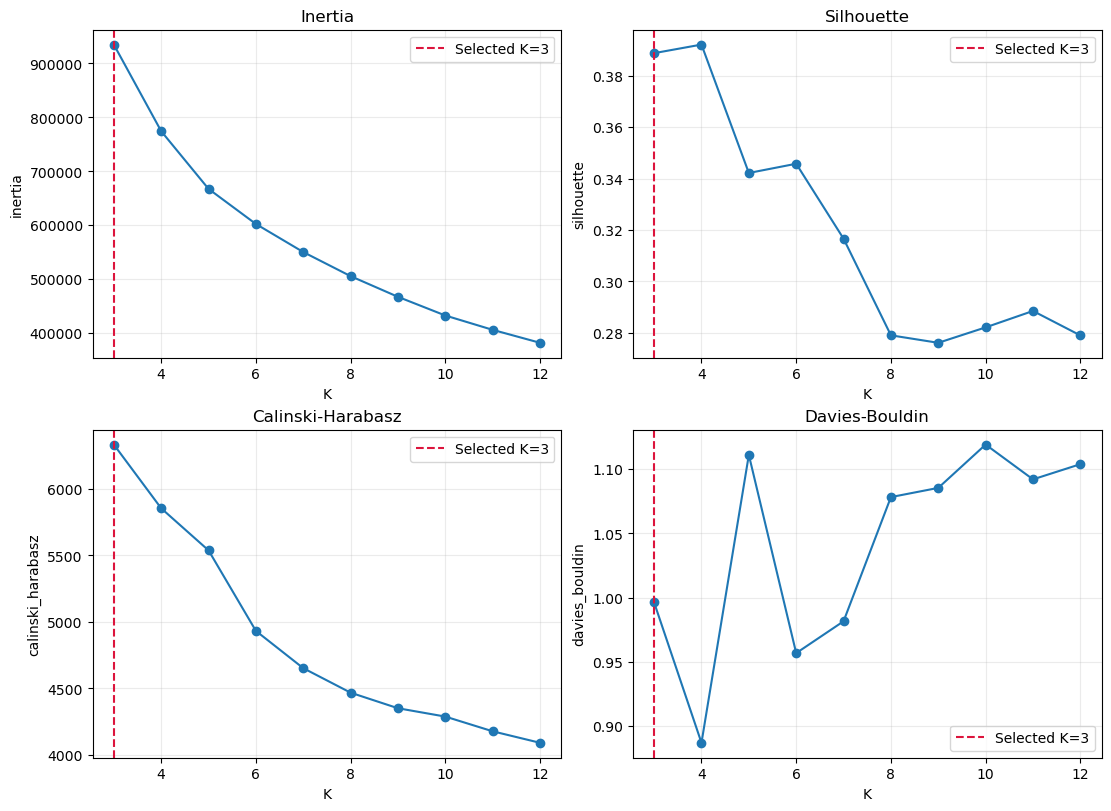

In [3]:
metric_idx = rng.choice(len(X_cluster), min(METRIC_SAMPLE_SIZE, len(X_cluster)), replace=False)
X_metric = X_cluster[metric_idx]
results, models = [], {}
for k in K_VALUES:
    model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_cluster)
    labels_metric = labels[metric_idx]
    shares = np.bincount(labels, minlength=k) / len(labels)
    environmental_centers = model.cluster_centers_[:, :n_components]
    d = np.linalg.norm(environmental_centers[:, None, :] - environmental_centers[None, :, :], axis=2)
    np.fill_diagonal(d, np.nan)
    results.append({'K': k, 'inertia': model.inertia_,
                    'silhouette': silhouette_score(X_metric, labels_metric),
                    'calinski_harabasz': calinski_harabasz_score(X_metric, labels_metric),
                    'davies_bouldin': davies_bouldin_score(X_metric, labels_metric),
                    'ecological_separation': np.nanmin(d),
                    'min_class_share': shares.min()})
    models[k] = model
metrics = pd.DataFrame(results)
eligible = metrics['min_class_share'] >= MIN_CLASS_SHARE
if not eligible.any():
    eligible[:] = True
    print('Warning: all candidates contain a class below 1%; the minimum-share constraint was relaxed.')
directions = {'silhouette': False, 'calinski_harabasz': False,
              'davies_bouldin': True, 'ecological_separation': False}
ranks = [metrics.loc[eligible, c].rank(ascending=a) for c, a in directions.items()]
metrics['composite_rank'] = np.nan
metrics.loc[eligible, 'composite_rank'] = pd.concat(ranks, axis=1).mean(axis=1)
best_k = int(metrics.loc[eligible].sort_values(['composite_rank', 'K']).iloc[0]['K'])
metrics['selected'] = metrics['K'].eq(best_k)
print(f'Composite selection: K = {best_k}')
metrics.to_excel(OUTPUT_DIR / 'K_sensitivity.xlsx', sheet_name='K selection', index=False)

display(metrics.round(4))
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, col, title in zip(axes.ravel(), ['inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin'],
                          ['Inertia', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']):
    ax.plot(metrics['K'], metrics[col], marker='o')
    ax.axvline(best_k, color='crimson', linestyle='--', label=f'Selected K={best_k}')
    ax.set(title=title, xlabel='K', ylabel=col); ax.grid(alpha=.25); ax.legend()
fig.savefig(OUTPUT_DIR / 'K_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()


# 4. Spatial-weight sensitivity and in-memory classification

In [4]:
k = best_k
sensitivity_models = {}
for weight in SPATIAL_WEIGHTS:
    if weight == SPATIAL_WEIGHT:
        sensitivity_models[weight] = models[best_k]
    else:
        weighted_sample = np.column_stack([X_pca, np.sqrt(weight) * XY_sample_m / SPATIAL_SCALE_M])
        sensitivity_models[weight] = KMeans(n_clusters=best_k, n_init=N_INIT, random_state=RANDOM_STATE).fit(weighted_sample)
    print(f'Sensitivity model: K={best_k}, weight={weight:g}', flush=True)

label_maps, stats = {}, {}
for weight in SPATIAL_WEIGHTS:
    raw = sensitivity_models[weight].labels_
    sample_means = np.vstack([X_sample[raw == c].mean(axis=0) for c in range(k)])
    order = np.argsort(sample_means[:, FEATURES.index('MAT')])
    label_map = np.empty(k, dtype='int16')
    label_map[order] = np.arange(1, k + 1, dtype='int16')
    label_maps[weight] = label_map
    stats[weight] = {'counts': np.zeros(k, dtype='int64'),
                'sums': np.zeros((k, len(FEATURES)), dtype='float64'),
                'area_m2': np.zeros(k, dtype='float64')}

source_profile = output_profile.copy()
source_profile.update(dtype='int16', count=1, nodata=0, compress='lzw', predictor=2)
if 'albers_memory' in globals():
    for mem in albers_memory.values():
        mem.close()
albers_memory = {weight: MemoryFile() for weight in SPATIAL_WEIGHTS}
with ExitStack() as source_stack:
    source_memory = {weight: source_stack.enter_context(MemoryFile()) for weight in SPATIAL_WEIGHTS}
    temporary_paths = {weight: mem.name for weight, mem in source_memory.items()}
    with ExitStack() as stack:
        sources = [stack.enter_context(rasterio.open(p)) for p in FEATURE_PATHS]
        crop_src = stack.enter_context(rasterio.open(CROPLAND_PATH))
        writers = {weight: stack.enter_context(rasterio.open(temporary_paths[weight], 'w', **source_profile))
                   for weight in SPATIAL_WEIGHTS}
        for row in range(ref_shape[0]):
            w = Window(0, row, ref_shape[1], 1)
            crop = crop_src.read(1, window=w, masked=True)
            values = read_features(sources, w)
            valid = ((~np.ma.getmaskarray(crop).ravel()) & (crop.data.ravel() > 0)
                     & np.isfinite(values).all(axis=1))
            valid_values, valid_area = values[valid], crop.data.ravel()[valid]
            if valid.any():
                environment_values = pca.transform(scaler.transform(valid_values))
                valid_cols = np.flatnonzero(valid)
                valid_rows = np.full(valid_cols.size, row, dtype=np.int32)
                lon, lat = xy(ref_transform, valid_rows, valid_cols, offset='center')
                x_m, y_m = transform_coords(ref_crs, ALBERS_CRS, lon, lat)
                spatial_coordinates = np.column_stack([x_m, y_m]) / SPATIAL_SCALE_M
            for weight in SPATIAL_WEIGHTS:
                out = np.zeros(ref_shape[1], dtype='int16')
                if valid.any():
                    transformed = np.column_stack([environment_values, np.sqrt(weight) * spatial_coordinates])
                    labels = label_maps[weight][sensitivity_models[weight].predict(transformed)]
                    out[valid] = labels
                    for cid in range(1, k + 1):
                        use = labels == cid
                        if use.any():
                            stats[weight]['counts'][cid - 1] += use.sum()
                            stats[weight]['sums'][cid - 1] += valid_values[use].sum(axis=0)
                            stats[weight]['area_m2'][cid - 1] += valid_area[use].sum()
                writers[weight].write(out.reshape(1, -1), 1, window=w)

    left, bottom, right, top = array_bounds(ref_shape[0], ref_shape[1], ref_transform)
    albers_transform, albers_width, albers_height = calculate_default_transform(
        ref_crs, ALBERS_CRS, ref_shape[1], ref_shape[0], left, bottom, right, top,
        resolution=ALBERS_RESOLUTION_M
    )
    albers_paths = {}
    for weight in SPATIAL_WEIGHTS:
        albers_path = albers_memory[weight].name
        albers_profile = source_profile.copy()
        albers_profile.update(crs=ALBERS_CRS, transform=albers_transform,
                              width=albers_width, height=albers_height)
        with rasterio.open(temporary_paths[weight]) as src, rasterio.open(albers_path, 'w', **albers_profile) as dst:
            reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                      src_transform=src.transform, src_crs=src.crs, src_nodata=0,
                      dst_transform=albers_transform, dst_crs=ALBERS_CRS, dst_nodata=0,
                      resampling=Resampling.nearest)
        albers_paths[weight] = albers_path

def ecological_name(z):
    idx = np.argsort(np.abs(z))[-2:][::-1]
    return ' / '.join(('High ' if z[i] >= 0 else 'Low ') + FEATURES[i] for i in idx)

profile_tables, z_profiles_by_weight, class_names_by_weight = {}, {}, {}
for weight in SPATIAL_WEIGHTS:
    means = stats[weight]['sums'] / stats[weight]['counts'][:, None]
    z = (means - scaler.mean_) / scaler.scale_
    names = [ecological_name(row) for row in z]
    table = pd.DataFrame(means, columns=FEATURES)
    table.insert(0, 'ecological_label', names)
    table.insert(0, 'cropland_area_km2', stats[weight]['area_m2'] / 1_000_000)
    table.insert(0, 'pixel_share', stats[weight]['counts'] / stats[weight]['counts'].sum())
    table.insert(0, 'pixel_count', stats[weight]['counts'])
    table.insert(0, 'class_id', np.arange(1, k + 1))
    z_table = pd.DataFrame(z, columns=FEATURES, index=np.arange(1, k + 1))
    z_table.index.name = 'class_id'
    profile_tables[weight], z_profiles_by_weight[weight], class_names_by_weight[weight] = table, z, names
    print(f'K={k}, spatial weight={weight:g}')
    display(table.round(3))
model_bundle = {'features': FEATURES, 'scaler': scaler, 'pca': pca, 'models': {weight: sensitivity_models[weight] for weight in SPATIAL_WEIGHTS},
             'label_maps': label_maps, 'selected_k': best_k, 'crs': ALBERS_CRS.to_wkt(),
             'spatial_scale_m': SPATIAL_SCALE_M, 'selection_spatial_weight': SPATIAL_WEIGHT, 'spatial_weights': SPATIAL_WEIGHTS}

weight_profiles = pd.concat([
    profile_tables[w].assign(Spatial_weight=w) for w in SPATIAL_WEIGHTS], ignore_index=True)
weight_standardized = pd.concat([
    pd.DataFrame(z_profiles_by_weight[w], columns=FEATURES)
      .assign(class_id=np.arange(1, best_k + 1), Spatial_weight=w)
    for w in SPATIAL_WEIGHTS], ignore_index=True)
with pd.ExcelWriter(OUTPUT_DIR / 'spatial_weight_sensitivity.xlsx', engine='openpyxl') as writer:
    weight_profiles.to_excel(writer, sheet_name='Class profiles', index=False)
    weight_standardized.to_excel(writer, sheet_name='Standardized profiles', index=False)


Sensitivity model: K=3, weight=0
Sensitivity model: K=3, weight=0.25
Sensitivity model: K=3, weight=0.5
Sensitivity model: K=3, weight=1
K=3, spatial weight=0


,class_id,pixel_count,pixel_share,cropland_area_km2,ecological_label,MAP,MAT,pH,SOC,srad,TN,vapr,CEC,Clay
0,1,1012404,0.182,530260.677,High CEC / High TN,602.462,4.068,6.619,27.524,13834.295,2.268,0.743,22.695,19.984
1,2,2131181,0.383,1295188.103,High pH / Low MAP,468.714,9.014,7.926,7.451,15466.432,0.746,0.844,11.185,15.951
2,3,2415250,0.434,1049586.230,High MAP / High vapr,1301.200,17.014,5.854,14.204,14020.826,1.236,1.608,11.594,27.782


K=3, spatial weight=0.25


,class_id,pixel_count,pixel_share,cropland_area_km2,ecological_label,MAP,MAT,pH,SOC,srad,TN,vapr,CEC,Clay
0,1,961483,0.173,536729.990,High CEC / Low MAT,562.333,3.314,6.716,26.966,13879.088,2.214,0.711,22.799,19.983
1,2,2090929,0.376,1259894.533,High pH / Low MAP,467.064,9.083,7.930,7.430,15493.031,0.743,0.844,11.079,15.799
2,3,2506423,0.451,1078410.487,High MAP / High vapr,1290.406,16.855,5.861,14.598,14000.881,1.272,1.591,11.862,27.561


K=3, spatial weight=0.5


,class_id,pixel_count,pixel_share,cropland_area_km2,ecological_label,MAP,MAT,pH,SOC,srad,TN,vapr,CEC,Clay
0,1,965768,0.174,549693.313,High CEC / Low MAT,555.249,3.207,6.746,26.272,13900.000,2.163,0.710,22.658,20.215
1,2,2059892,0.371,1238287.796,High pH / Low MAP,464.367,9.118,7.936,7.494,15513.638,0.748,0.842,11.021,15.653
2,3,2533175,0.456,1087053.901,High MAP / High vapr,1286.444,16.795,5.869,14.702,13994.639,1.279,1.586,11.935,27.460


K=3, spatial weight=1


,class_id,pixel_count,pixel_share,cropland_area_km2,ecological_label,MAP,MAT,pH,SOC,srad,TN,vapr,CEC,Clay
0,1,1015084,0.183,591547.742,High CEC / Low MAT,549.486,3.308,6.818,24.591,13948.201,2.045,0.714,22.034,20.461
1,2,1987407,0.358,1187715.504,High pH / Low MAP,460.604,9.194,7.943,7.665,15545.954,0.758,0.840,10.973,15.406
2,3,2556344,0.460,1095771.764,High MAP / High vapr,1282.453,16.740,5.877,14.809,13995.272,1.287,1.581,11.987,27.359


# 5. Spatial-weight comparison and standardized profiles

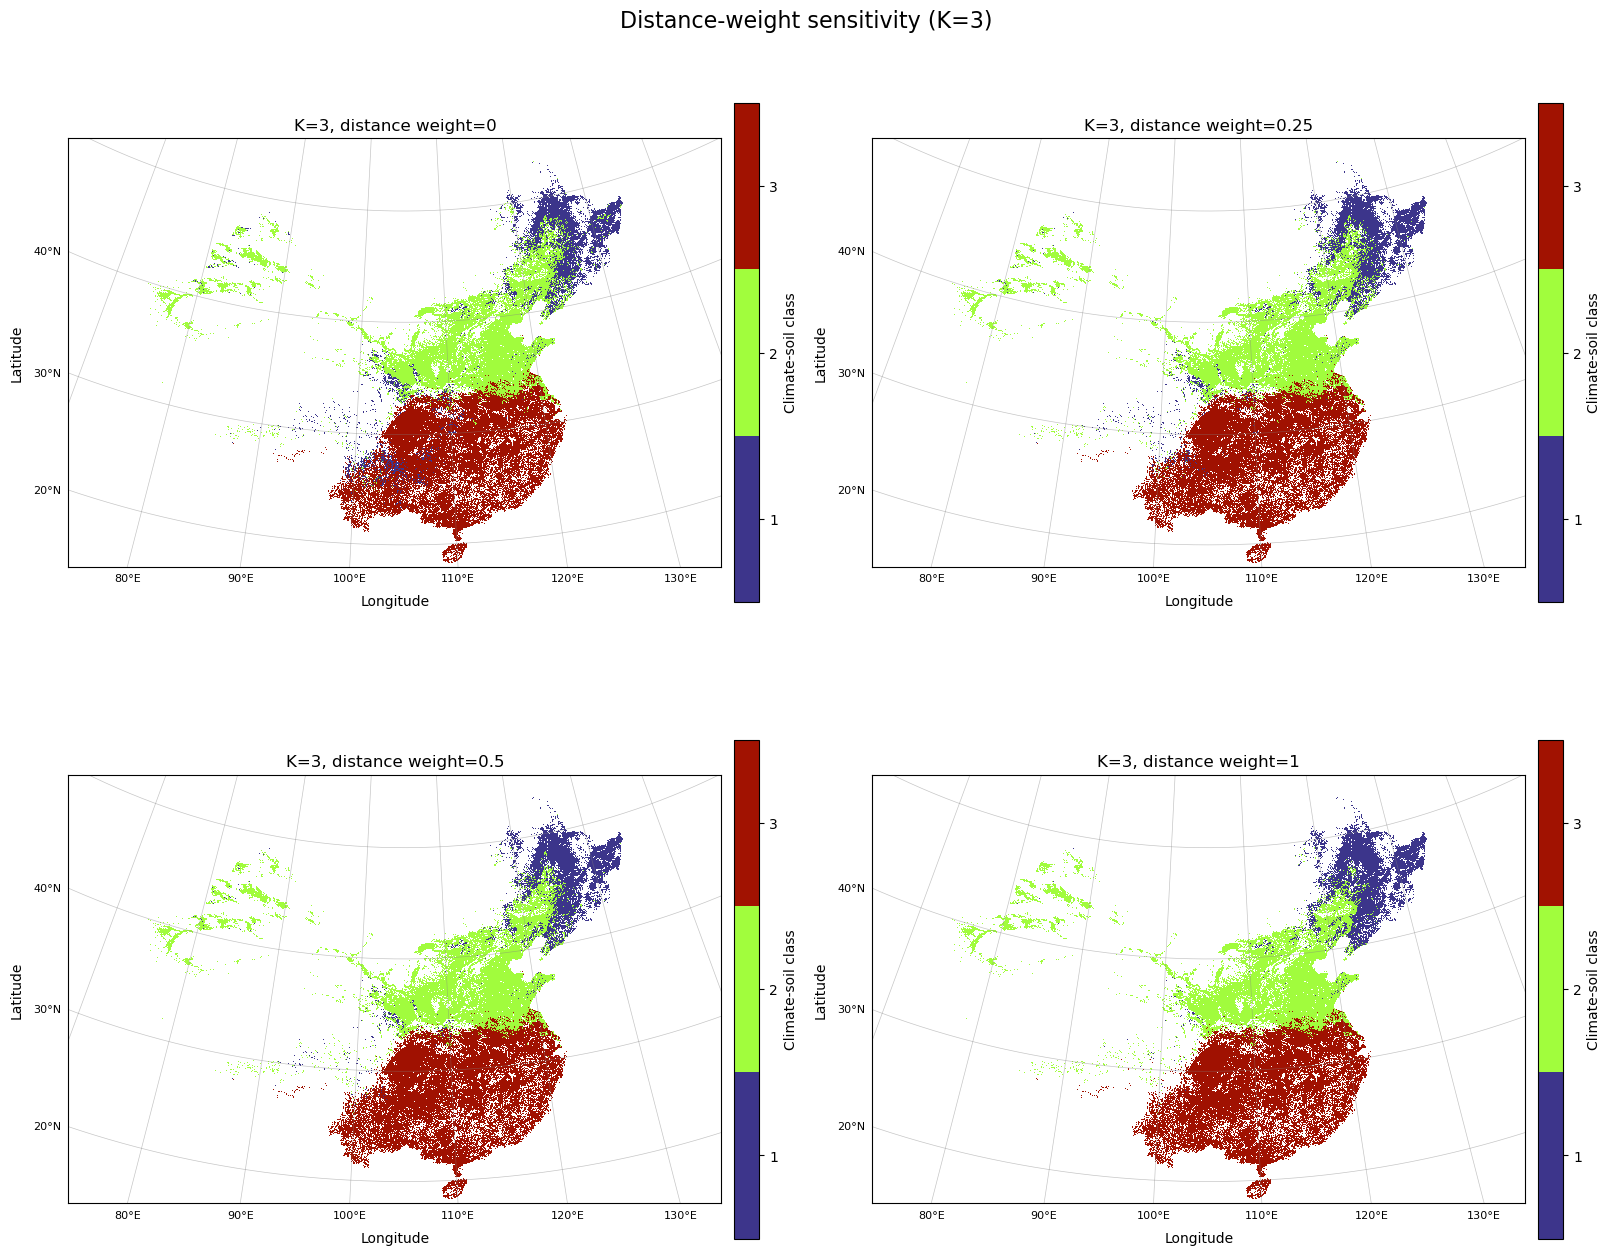

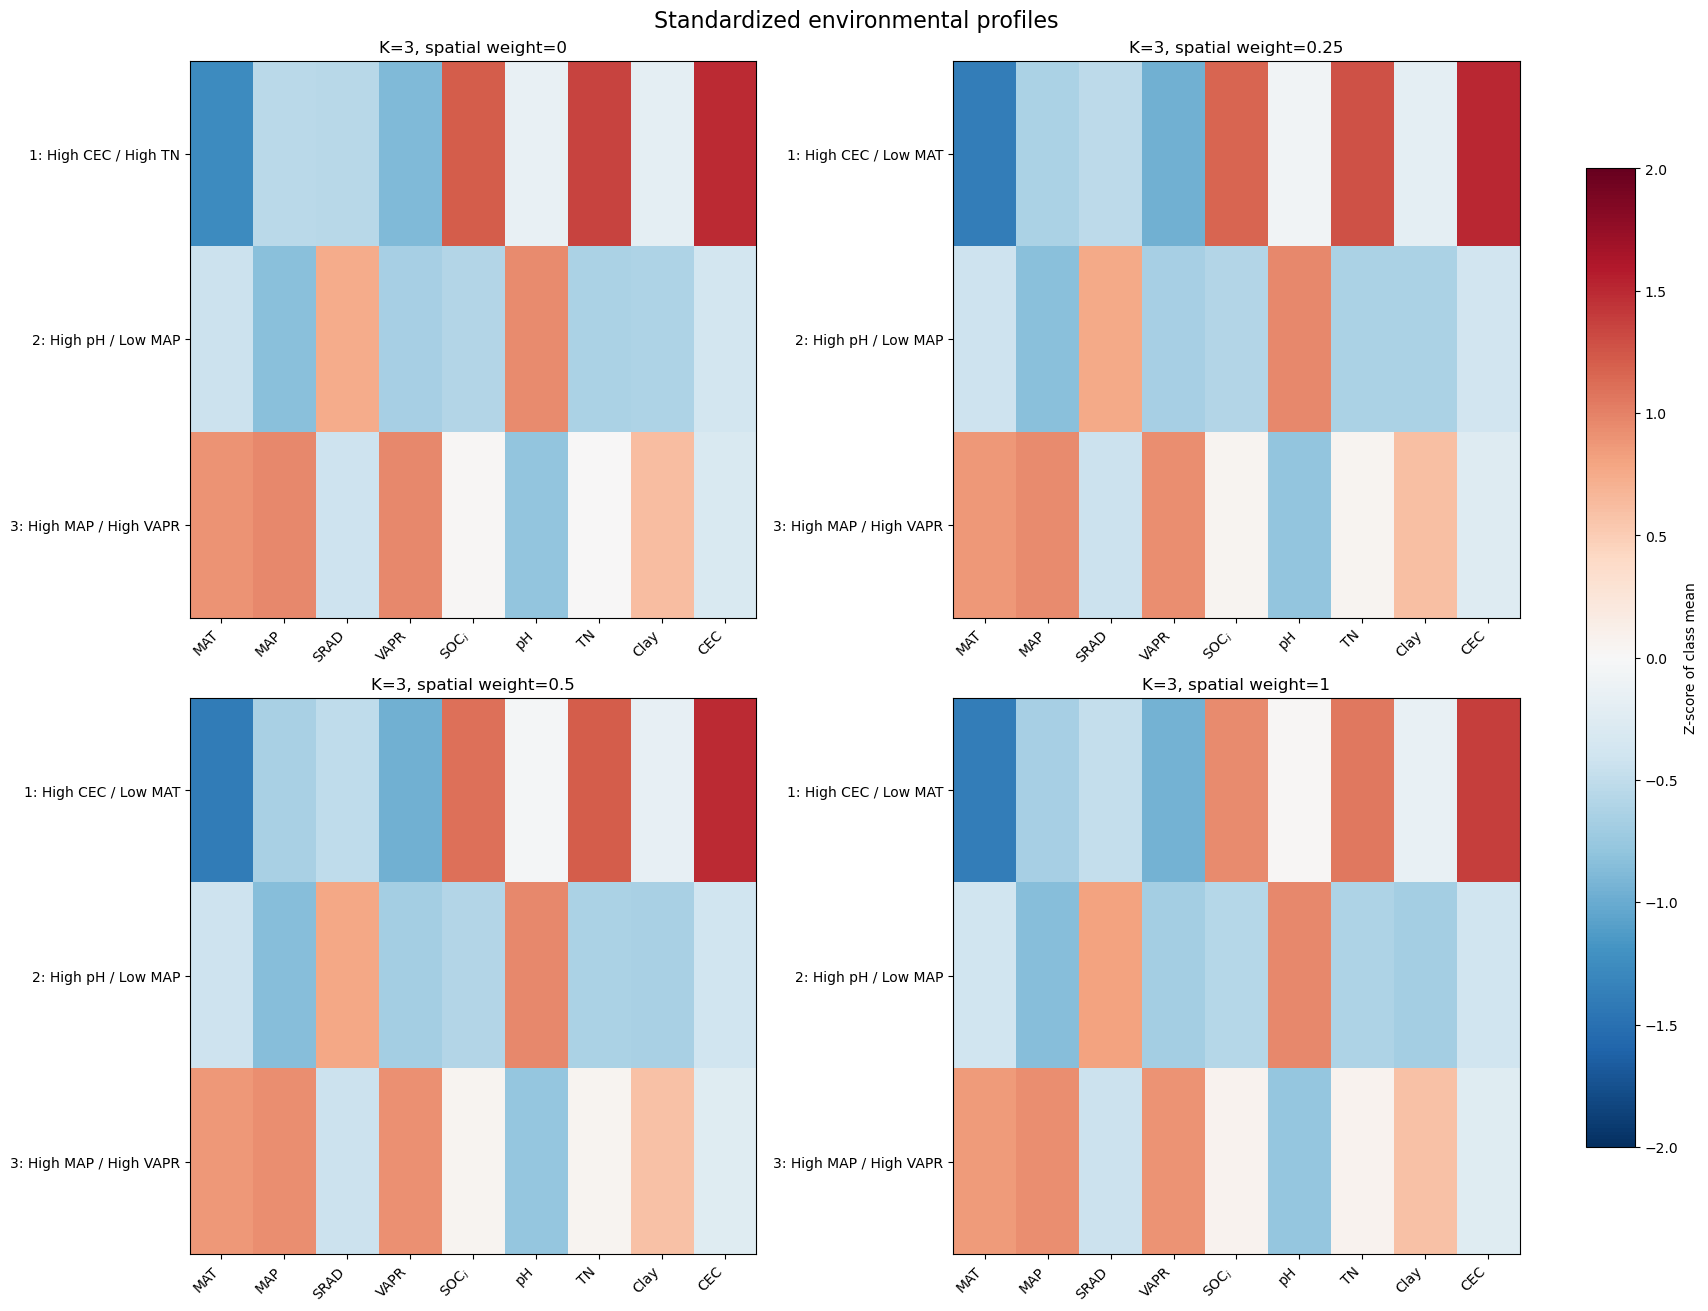

In [5]:
def plot_classification(ax, weight, colorbar=True):
    k = best_k
    cmap = ListedColormap(plt.cm.turbo(np.linspace(.05, .95, k)))
    with rasterio.open(albers_paths[weight]) as src:
        data, bounds = src.read(1, masked=True), src.bounds
    im = ax.imshow(data, cmap=cmap, vmin=.5, vmax=k + .5,
                   extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                   interpolation='nearest')
    if colorbar:
        cb = ax.figure.colorbar(im, ax=ax, ticks=np.arange(1, k + 1), shrink=.80, pad=.02)
        cb.set_label('Climate-soil class')
    ax.set_title(f'K={k}, distance weight={weight:g}')
    add_lonlat_grid(ax, bounds, ALBERS_CRS)
    ax.set_aspect('equal')
    return im

fig, axes = plt.subplots(2, 2, figsize=(16, 13), constrained_layout=True)
for ax, weight in zip(axes.ravel(), SPATIAL_WEIGHTS):
    plot_classification(ax, weight)
fig.suptitle(f'Distance-weight sensitivity (K={best_k})', fontsize=16)
fig.savefig(OUTPUT_DIR / 'spatial_weight_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

HEATMAP_FEATURES = ['MAT', 'MAP', 'srad', 'vapr', 'SOC', 'pH', 'TN', 'Clay', 'CEC']
def heatmap_label(text):
    return text.replace('vapr', 'VAPR').replace('srad', 'SRAD').replace('SOC', r'SOC$_i$')

heatmap_indices = [FEATURES.index(name) for name in HEATMAP_FEATURES]
fig, axes = plt.subplots(2, 2, figsize=(17, 13), constrained_layout=True)
for ax, weight in zip(axes.ravel(), SPATIAL_WEIGHTS):
    heat = ax.imshow(z_profiles_by_weight[weight][:, heatmap_indices], cmap='RdBu_r',
                     vmin=-2, vmax=2, aspect='auto')
    ax.set_xticks(np.arange(len(HEATMAP_FEATURES)), [heatmap_label(name) for name in HEATMAP_FEATURES],
                  rotation=45, ha='right')
    ax.set_yticks(np.arange(best_k),
                  [f'{i}: {heatmap_label(name)}' for i, name in enumerate(class_names_by_weight[weight], 1)])
    ax.set_title(f'K={best_k}, spatial weight={weight:g}')
fig.colorbar(heat, ax=axes.ravel().tolist(), label='Z-score of class mean', shrink=.82)
fig.suptitle('Standardized environmental profiles', fontsize=16)
fig.savefig(OUTPUT_DIR / 'class_profile_distance_weight_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

summary = {'selected_k': best_k, 'selection_spatial_weight': SPATIAL_WEIGHT,
           'spatial_weights': list(SPATIAL_WEIGHTS), 'sample_size': int(len(X_sample)),
           'pca_components': n_components,
           'pca_cumulative_variance': float(pca.explained_variance_ratio_.sum()),
           'spatial_scale_m': SPATIAL_SCALE_M,
           'output_crs_name': ALBERS_NAME, 'output_crs_wkt': ALBERS_CRS.to_wkt(),
           'map_coordinate_labels': 'longitude/latitude (degrees)',
           'classification_storage': 'In memory only; no classification GeoTIFF export',
           'valid_classified_pixels': {str(w): int(stats[w]['counts'].sum()) for w in SPATIAL_WEIGHTS}}
summary.update(run_metadata)

# 6. Field-site assignment and region export

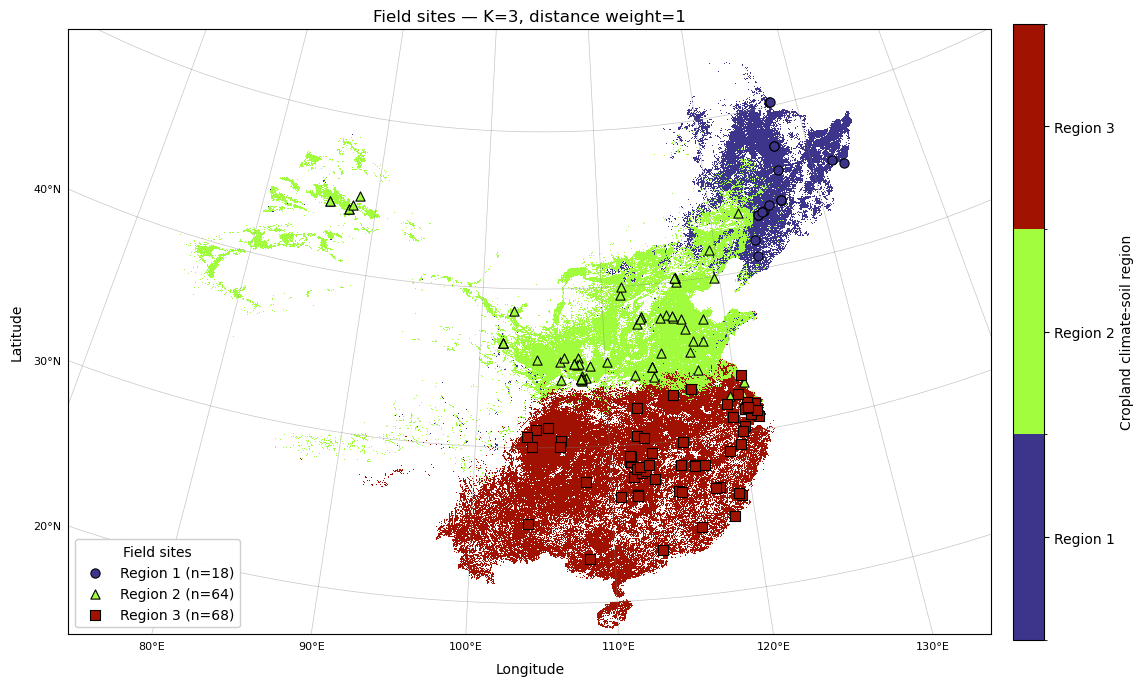

Input: 708 rows; unique three-column site keys: 150 records; Unique coordinate pairs: 132; Unassigned: 0.


,Region,Site_count
0,Region 1,18
1,Region 2,64
2,Region 3,68


,Serial No.,Longitude,Latitude,MAP,MAT,pH,SOC,srad,TN,vapr,CEC,Clay,Status,Region_ID,Region,Distance_to_Region_1,Distance_to_Region_2,Distance_to_Region_3
0,1,108.12,34.20,645.0,12.966667,8.116500,6.833000,14364.083008,0.7455,1.155000,12.777400,24.830000,assigned,2,Region 2,5.129682,1.931508,3.074023
1,2,108.07,34.28,659.0,12.791667,8.116500,6.833000,14267.916992,0.7455,1.135000,13.061300,22.000000,assigned,2,Region 2,5.079749,1.822201,3.128236
2,3,121.40,30.90,1002.0,16.183332,6.103000,12.716001,14696.500000,1.3695,1.620000,11.835649,24.600000,assigned,3,Region 3,5.075562,4.212044,2.358768
3,4,116.60,36.95,586.0,13.216666,8.033500,6.352000,16404.083984,0.5000,1.203333,7.846399,13.340000,assigned,2,Region 2,5.142743,1.885883,4.433738
4,5,121.29,31.74,1033.0,15.366666,6.531500,13.105499,14968.416992,1.2725,1.580833,9.432449,21.190001,assigned,3,Region 3,5.026250,3.846284,2.609896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,125,113.80,34.13,698.0,14.858334,8.032001,6.318500,14972.916992,0.6285,1.281667,10.920100,17.545000,assigned,2,Region 2,5.049488,1.879504,3.175302
146,126,122.54,43.73,433.0,6.833334,7.958500,1.770000,15300.333008,0.1795,0.760833,4.337900,5.475000,assigned,2,Region 2,4.820500,2.966067,6.358652
147,127,112.26,32.29,970.0,15.716666,6.958500,4.758500,13535.000000,0.5740,1.469167,17.548099,41.400002,assigned,3,Region 3,5.766949,4.293923,2.648935
148,128,115.10,32.92,898.0,15.308333,7.596000,7.057500,14934.583008,0.8660,1.428333,25.359747,26.590000,assigned,3,Region 3,4.525777,3.075376,2.654411


Site results: c:\Meta\data_SD\meta_test\meta_data_region.xlsx


In [6]:
from matplotlib.colors import BoundaryNorm

site_output = OUTPUT_DIR
site_excel = SITE_EXCEL
site_weight = SITE_WEIGHT
site_bundle = model_bundle
site_k = int(site_bundle['selected_k'])
site_scaler, site_pca = site_bundle['scaler'], site_bundle['pca']
if site_weight not in site_bundle['models']:
    raise ValueError(f"No fitted model for weight={site_weight:g}; available weights: {list(site_bundle['models'])}")
site_model = site_bundle['models'][site_weight]
site_label_map = np.asarray(site_bundle['label_maps'][site_weight])
site_features = list(site_bundle['features'])
site_crs = rasterio.crs.CRS.from_wkt(site_bundle['crs'])
site_scale = float(site_bundle['spatial_scale_m'])
if site_model.n_clusters != site_k:
    raise ValueError(f'Fitted model has K={site_model.n_clusters}; requested K={site_k}; generate the matching model first.')
site_region_ids = np.arange(1, site_k + 1)
site_region_names = [f'Region {rid}' for rid in site_region_ids]
assert sorted(site_label_map.tolist()) == site_region_ids.tolist()
assert site_scale > 0
site_map_path = albers_paths[site_weight]

site_keys = ['Serial No.', 'Longitude', 'Latitude']
site_source = pd.read_excel(site_excel)
if site_source.empty:
    raise ValueError('The site workbook is empty.')
site_table = site_source[site_keys].copy()
for col in ['Longitude', 'Latitude']:
    site_table[col] = pd.to_numeric(site_table[col], errors='raise')
if site_table.isna().any().any():
    raise ValueError('Missing site identifier or coordinates in the input workbook.')
site_table = site_table.drop_duplicates(site_keys).reset_index(drop=True)
if not (site_table.Longitude.between(-180, 180) & site_table.Latitude.between(-90, 90)).all():
    raise ValueError('Coordinates are outside the WGS84 longitude/latitude range.')
site_lon = site_table.Longitude.to_numpy()
site_lat = site_table.Latitude.to_numpy()
for feature in site_features:
    with rasterio.open(RASTER_DIR / f'{feature}_cropped.tif') as src:
        sx, sy = transform_coords('EPSG:4326', src.crs, site_lon, site_lat)
        samples = np.ma.vstack(list(src.sample(zip(sx, sy), indexes=1, masked=True)))[:, 0]
        site_table[feature] = samples.astype('float64').filled(np.nan)
site_valid = np.isfinite(site_table[site_features].to_numpy()).all(axis=1)
site_table['Status'] = np.where(site_valid, 'assigned', 'missing raster features')
site_x, site_y = transform_coords('EPSG:4326', site_crs, site_lon, site_lat)
site_xy = np.column_stack([site_x, site_y])
if not np.isfinite(site_xy).all():
    raise ValueError('Invalid projected Albers site coordinates.')

site_table['Region_ID'] = pd.Series(pd.NA, index=site_table.index, dtype='Int64')
site_table['Region'] = pd.Series(pd.NA, index=site_table.index, dtype='string')
for rid in site_region_ids:
    site_table[f'Distance_to_Region_{rid}'] = np.nan
if site_valid.any():
    site_environment = site_pca.transform(site_scaler.transform(
        site_table.loc[site_valid, site_features].to_numpy(dtype='float64')))
    site_transformed = np.column_stack([
        site_environment, np.sqrt(site_weight) * site_xy[site_valid] / site_scale])
    site_distances = site_model.transform(site_transformed)
    site_raw_labels = site_distances.argmin(axis=1)
    assert np.array_equal(site_raw_labels, site_model.predict(site_transformed))
    site_regions = site_label_map[site_raw_labels]
    site_table.loc[site_valid, 'Region_ID'] = site_regions
    site_table.loc[site_valid, 'Region'] = [f'Region {r}' for r in site_regions]
    for raw_label, rid in enumerate(site_label_map):
        site_table.loc[site_valid, f'Distance_to_Region_{rid}'] = site_distances[:, raw_label]

assert site_table.groupby(['Longitude', 'Latitude'])['Region_ID'].nunique().le(1).all()
site_counts = (site_table['Region'].value_counts().reindex(
    site_region_names, fill_value=0).rename_axis('Region').reset_index(name='Site_count'))
site_result_path = NOTEBOOK_DIR / 'meta_data_region.xlsx'
site_match_keys = site_source[site_keys].copy()
for col in ['Longitude', 'Latitude']:
    site_match_keys[col] = pd.to_numeric(site_match_keys[col], errors='raise')
site_region_lookup = site_table.set_index(site_keys)['Region']
assert site_region_lookup.index.is_unique
site_record_regions = site_region_lookup.reindex(pd.MultiIndex.from_frame(site_match_keys))
site_records = site_source.copy()
site_records['Region'] = site_record_regions.to_numpy()
with pd.ExcelWriter(site_result_path, engine='openpyxl') as writer:
    site_records.to_excel(writer, sheet_name='Records with regions', index=False)

site_colors = plt.cm.turbo(np.linspace(.05, .95, site_k))
site_cmap = ListedColormap(site_colors)
site_norm = BoundaryNorm(np.arange(.5, site_k + 1.5, 1), site_k)
with rasterio.open(site_map_path) as src:
    if src.crs != site_crs:
        raise ValueError('Classification CRS differs from the fitted model CRS.')
    site_background, site_bounds = src.read(1, masked=True), src.bounds
site_fig, site_ax = plt.subplots(figsize=(12, 8))
site_im = site_ax.imshow(site_background, cmap=site_cmap, norm=site_norm,
    extent=[site_bounds.left, site_bounds.right, site_bounds.bottom, site_bounds.top],
    interpolation='nearest')
add_lonlat_grid(site_ax, site_bounds, site_crs)
site_markers = ['o', '^', 's', 'D', 'v', 'P', '*', 'X', '<', '>']
for rid in site_region_ids:
    marker = site_markers[(rid - 1) % len(site_markers)]
    use = site_table['Region_ID'].eq(rid).fillna(False).to_numpy(dtype=bool)
    site_ax.scatter(site_xy[use, 0], site_xy[use, 1], s=44, marker=marker,
        facecolor=site_colors[rid - 1], edgecolor='black', linewidth=.8, zorder=5,
        label=f'Region {rid} (n={use.sum()})')
if (~site_valid).any():
    site_ax.scatter(site_xy[~site_valid, 0], site_xy[~site_valid, 1], marker='x',
                    color='black', label=f'Unassigned (n={(~site_valid).sum()})', zorder=6)
site_cb = site_fig.colorbar(site_im, ax=site_ax, ticks=site_region_ids, shrink=.8, pad=.02)
site_cb.ax.set_yticklabels(site_region_names)
site_cb.set_label('Cropland climate-soil region')
site_ax.legend(title='Field sites', loc='lower left', framealpha=.95)
site_ax.set(xlim=(site_bounds.left, site_bounds.right), ylim=(site_bounds.bottom, site_bounds.top),
            title=f'Field sites — K={site_k}, distance weight={site_weight:g}', xlabel='Longitude', ylabel='Latitude')
site_ax.set_xticks([])
site_ax.set_yticks([])
site_ax.xaxis.labelpad, site_ax.yaxis.labelpad = 20, 32
site_ax.set_aspect('equal')
site_fig.tight_layout()
plt.show()
print(f'Input: {len(site_source)} rows; unique three-column site keys: {len(site_table)} records; '
      f'Unique coordinate pairs: {len(site_table.drop_duplicates(["Longitude", "Latitude"]))}; '
      f'Unassigned: {(~site_valid).sum()}.')
display(site_counts)
display(site_table)
print('Site results:', site_result_path)

with rasterio.open(site_map_path) as src:
    site_grid = {'crs': src.crs.to_wkt(), 'transform': list(src.transform)[:6],
                 'height': src.height, 'width': src.width}
site_manifest = {
    'schema_version': 4,
    'raster_dir': os.path.relpath(RASTER_DIR, NOTEBOOK_DIR), 'k': site_k, 'weight': site_weight,
    'site_file': site_result_path.name,
    'records_sha256': hashlib.sha256(pd.read_excel(site_result_path, sheet_name='Records with regions')[site_keys + ['Region']]
        .to_json(orient='split', index=False, double_precision=15).encode('utf-8')).hexdigest(),
    'run_summary': summary,
    'classification_grid': site_grid,
    'classification_sha256': raster_values_sha256(site_map_path),
    'sklearn_version': version('scikit-learn'),
    'features': site_features, 'crs': site_crs.to_wkt(), 'spatial_scale_m': site_scale,
    'label_map': site_label_map.tolist(),
    'fitted_parameters': {'scaler': estimator_state(site_scaler),
                          'pca': estimator_state(site_pca), 'model': estimator_state(site_model)},
    'raster_inputs': run_metadata['inputs'],
}
state_path = OUTPUT_DIR / 'model_state.json'
state_path.write_text(json.dumps(site_manifest, ensure_ascii=False, indent=2), encoding='utf-8')
for mem in albers_memory.values():
    mem.close()